In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../Data/BrentOilPrices.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.set_index("Date", inplace=True)

df.head()

,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


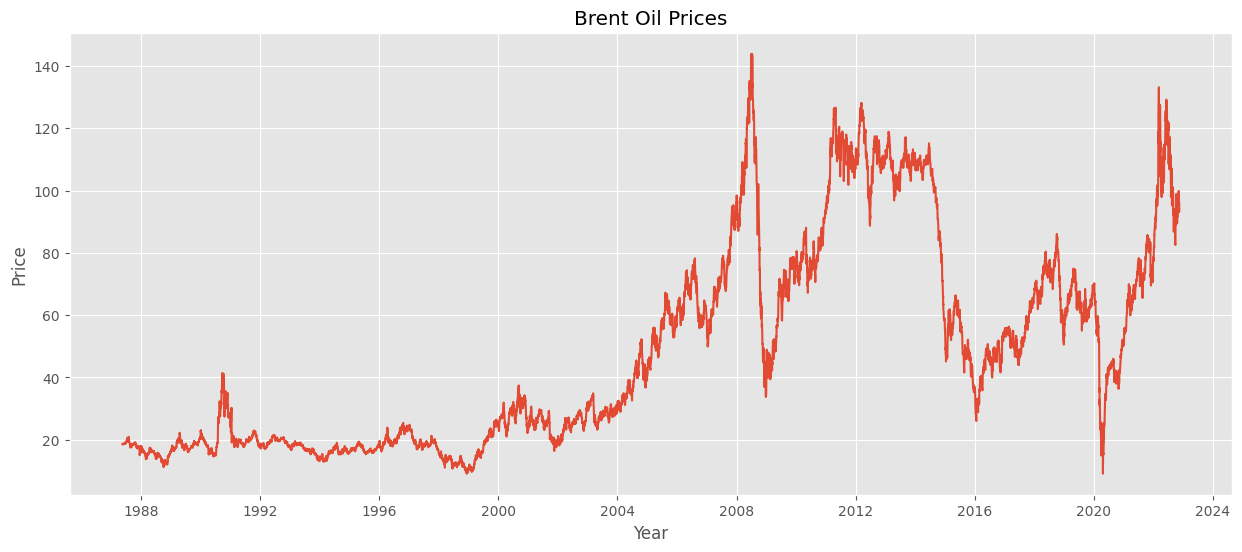

In [3]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df["Price"])

plt.title("Brent Oil Prices")

plt.xlabel("Year")

plt.ylabel("Price")

plt.show()

In [4]:
x = np.arange(len(df))

coefficients = np.polyfit(x, df["Price"], 1)

trend_line = np.polyval(coefficients, x)

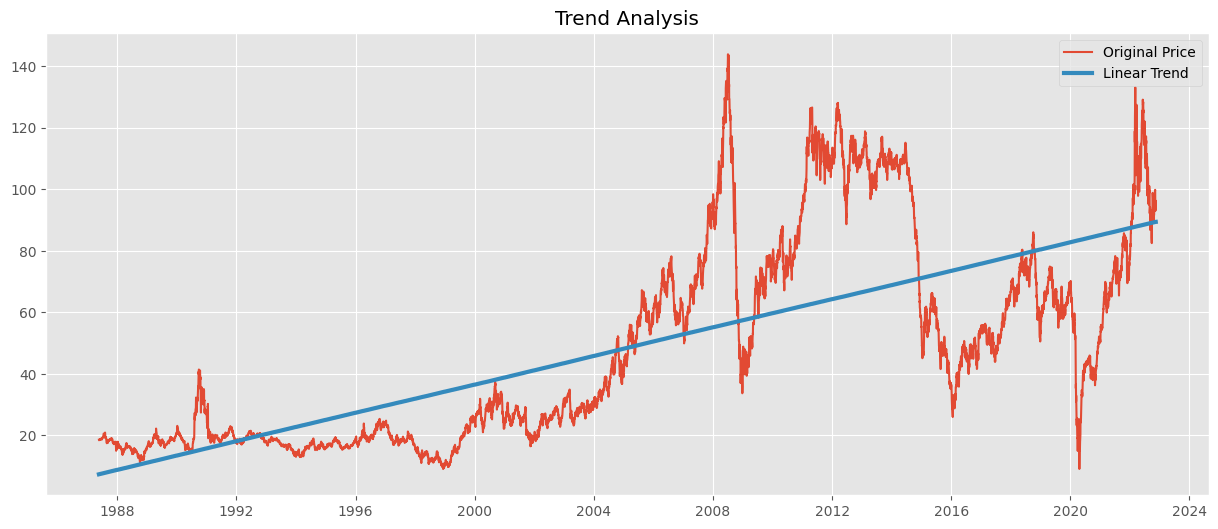

In [5]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df["Price"], label="Original Price")

plt.plot(df.index, trend_line,
         linewidth=3,
         label="Linear Trend")

plt.legend()

plt.title("Trend Analysis")

plt.show()

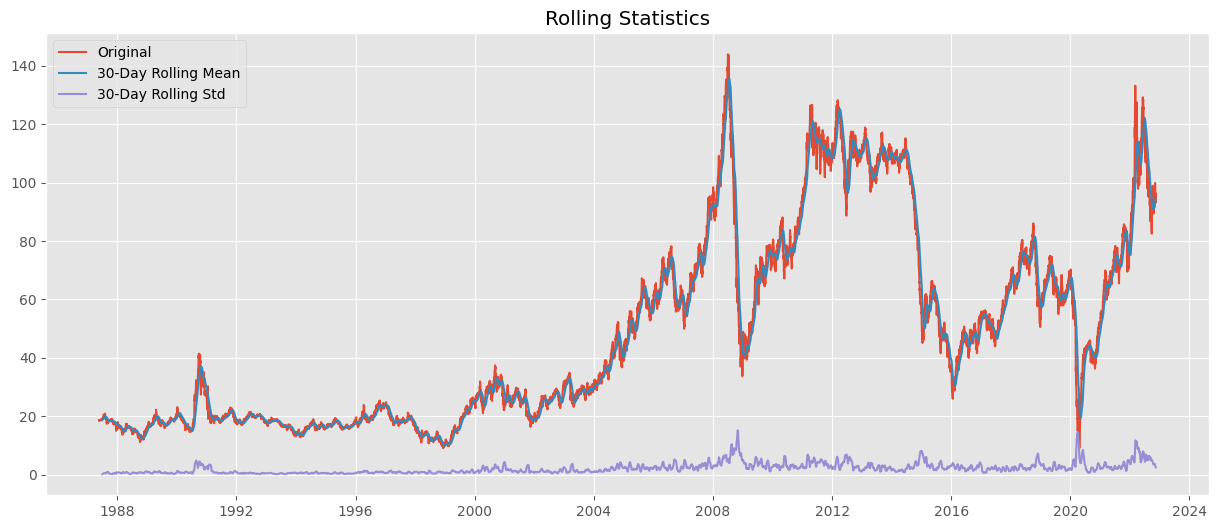

In [6]:
rolling_mean = df["Price"].rolling(window=30).mean()

rolling_std = df["Price"].rolling(window=30).std()
plt.figure(figsize=(15,6))

plt.plot(df["Price"], label="Original")

plt.plot(rolling_mean,
         label="30-Day Rolling Mean")

plt.plot(rolling_std,
         label="30-Day Rolling Std")

plt.legend()

plt.title("Rolling Statistics")

plt.show()

In [7]:
result = adfuller(df["Price"])

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print("\nCritical Values")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -1.9938560113924664
p-value : 0.2892735048934034

Critical Values
1%: -3.4310783342658615
5%: -2.861861876398633
10%: -2.566941329781918


In [8]:
if result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is NOT stationary.")

The series is NOT stationary.


In [9]:
df["Price_Diff"] = df["Price"].diff()
df["Price_Diff"].head()

Date
1987-05-20     NaN
1987-05-21   -0.18
1987-05-22    0.10
1987-05-25    0.05
1987-05-26    0.03
Name: Price_Diff, dtype: float64

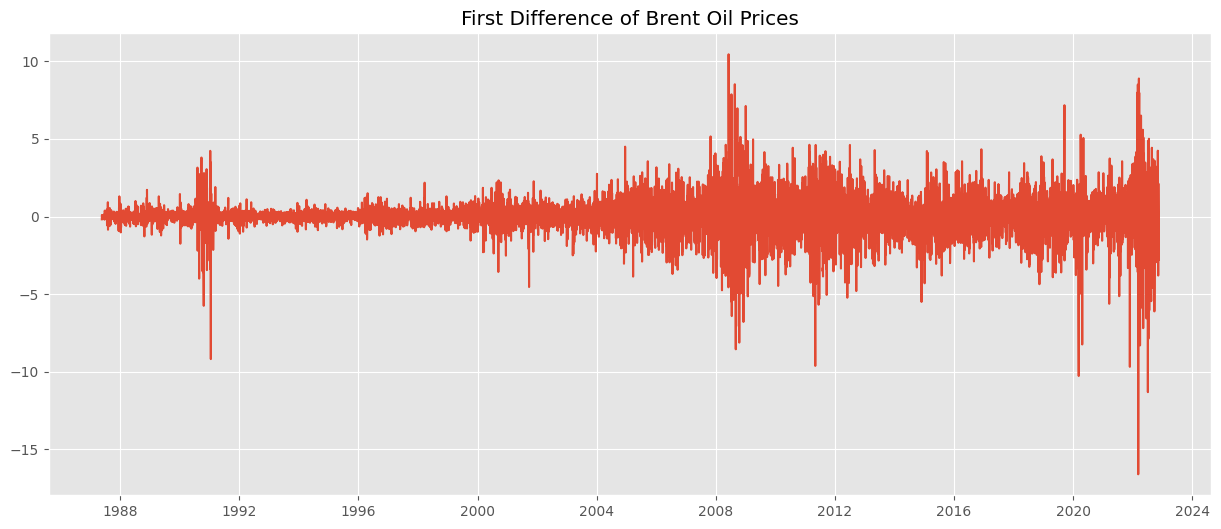

In [10]:
plt.figure(figsize=(15,6))

plt.plot(df["Price_Diff"])

plt.title("First Difference of Brent Oil Prices")

plt.show()

In [11]:
result_diff = adfuller(df["Price_Diff"].dropna())

print("ADF Statistic :", result_diff[0])

print("p-value :", result_diff[1])

print("\nCritical Values")

for key, value in result_diff[4].items():
    print(f"{key}: {value}")

ADF Statistic : -15.52936758004801
p-value : 2.2307405105163768e-28

Critical Values
1%: -3.4310783342658615
5%: -2.861861876398633
10%: -2.566941329781918


In [12]:
if result_diff[1] < 0.05:
    print("Differenced series is stationary.")
else:
    print("Differenced series is NOT stationary.")

Differenced series is stationary.


In [ ]:
volatility = df["Price"].rolling(30).std()
plt.figure(figsize=(15,6))

plt.plot(volatility)

plt.title("30-Day Rolling Volatility")

plt.xlabel("Year")

plt.ylabel("Standard Deviation")

plt.show()

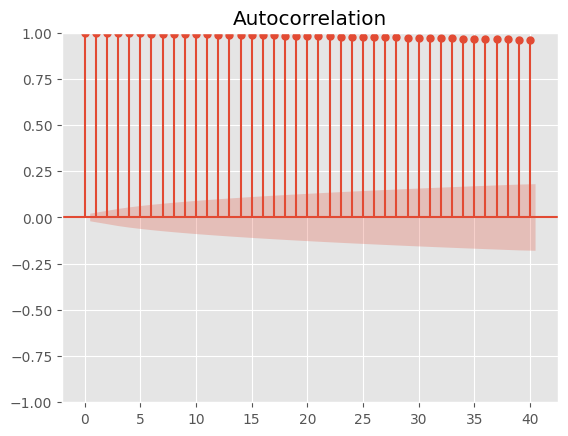

In [14]:
plot_acf(df["Price"].dropna(), lags=40)

plt.show()

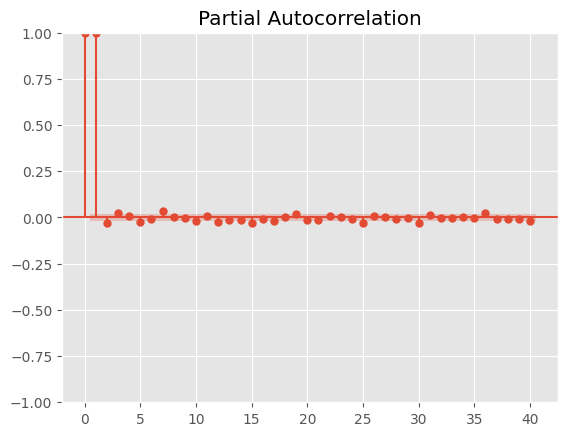

In [13]:
plot_pacf(df["Price"].dropna(), lags=40)

plt.show()